In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import skew, kurtosis

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

plt.style.use("default")

In [2]:
TRAIN_PATH = "../data/train-test.csv"
VALID_PATH = "../data/validation.csv"
DECEMBER_PATH = "../data/december-chart-inputs.csv"

train = pd.read_csv(TRAIN_PATH)
validation = pd.read_csv(VALID_PATH)
december = pd.read_csv(DECEMBER_PATH)

In [3]:
def dataset_summary(df, name):

    summary = pd.DataFrame({
        "Column": df.columns,
        "Data Type": df.dtypes.astype(str),
        "Missing": df.isna().sum(),
        "Missing %": (df.isna().mean()*100).round(2),
        "Unique Values": df.nunique()
    })

    print("="*70)
    print(name.upper())
    print("="*70)

    print(f"Shape: {df.shape}")
    print(f"Memory Usage: {df.memory_usage(deep=True).sum()/1024**2:.2f} MB")

    display(summary)

In [4]:
dataset_summary(train, "Training Data")

dataset_summary(validation, "Validation Data")

dataset_summary(december, "December Data")

TRAINING DATA
Shape: (48000, 14)
Memory Usage: 18.34 MB


,Column,Data Type,Missing,Missing %,Unique Values
load_id,load_id,object,0,0.00,48000
pickup,pickup,object,0,0.00,64
delivery,delivery,object,0,0.00,64
pickup_lat,pickup_lat,float64,0,0.00,64
pickup_lon,pickup_lon,float64,0,0.00,63
delivery_lat,delivery_lat,float64,0,0.00,64
delivery_lon,delivery_lon,float64,0,0.00,63
distance,distance,float64,0,0.00,21204
equipment,equipment,object,0,0.00,3
weight,weight,float64,300,0.62,23678


VALIDATION DATA
Shape: (12000, 13)
Memory Usage: 4.49 MB


,Column,Data Type,Missing,Missing %,Unique Values
load_id,load_id,object,0,0.00,12000
pickup,pickup,object,0,0.00,72
delivery,delivery,object,0,0.00,72
pickup_lat,pickup_lat,float64,0,0.00,72
pickup_lon,pickup_lon,float64,0,0.00,71
delivery_lat,delivery_lat,float64,0,0.00,72
delivery_lon,delivery_lon,float64,0,0.00,71
distance,distance,float64,0,0.00,9309
equipment,equipment,object,0,0.00,3
weight,weight,float64,165,1.38,9472


DECEMBER DATA
Shape: (31, 7)
Memory Usage: 0.01 MB


,Column,Data Type,Missing,Missing %,Unique Values
pickup,pickup,object,0,0.0,1
delivery,delivery,object,0,0.0,1
distance,distance,int64,0,0.0,1
equipment,equipment,object,0,0.0,1
weight,weight,int64,0,0.0,1
date,date,object,0,0.0,31
predicted_rate,predicted_rate,float64,31,100.0,0


In [5]:
print("Duplicate rows")

print(train.duplicated().sum())

print(validation.duplicated().sum())

print()

print("Duplicate load IDs")

print(train["load_id"].duplicated().sum())

print(validation["load_id"].duplicated().sum())

Duplicate rows
0
0

Duplicate load IDs
0
0


In [6]:
def missing_summary(df):

    missing = (
        df.isna()
          .sum()
          .to_frame("Missing")
    )

    missing["Percent"] = (
        missing["Missing"] / len(df) * 100
    ).round(2)

    missing = missing[missing["Missing"] > 0]

    return missing.sort_values(
        "Percent",
        ascending=False
    )

In [7]:
missing_summary(train)

,Missing,Percent
market_index,374,0.78
weight,300,0.62


In [8]:
missing_summary(validation)

,Missing,Percent
market_index,249,2.08
weight,165,1.38


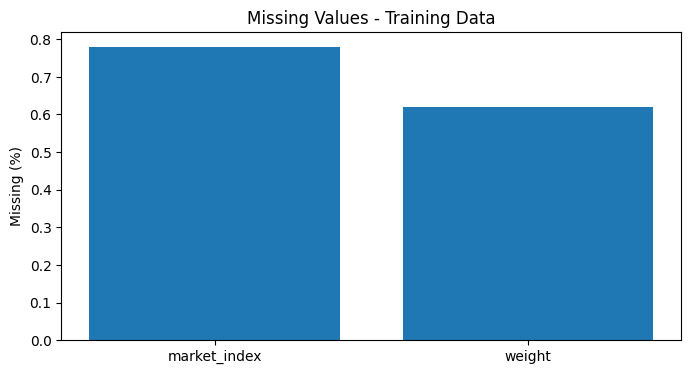

In [9]:
missing = missing_summary(train)

plt.figure(figsize=(8,4))

plt.bar(
    missing.index,
    missing["Percent"]
)

plt.ylabel("Missing (%)")

plt.title("Missing Values - Training Data")

plt.show()

In [10]:
train.dtypes.value_counts()

float64    9
object     5
Name: count, dtype: int64

In [11]:
target = train["posted_rate"]

target.describe()

count    48000.000000
mean      2373.980682
std       1486.493245
min         57.220000
25%       1251.555000
50%       2030.760000
75%       3330.750000
max      25533.000000
Name: posted_rate, dtype: float64

### Target Distribution - Key Findings

The target variable, `posted_rate`, is positively skewed:

- Mean: $2,373.98
- Median: $2,030.76
- Standard deviation: $1,486.49
- Range: $57.22–$25,533.00
- Skewness: 1.90
- Kurtosis: 13.28

The mean being substantially higher than the median indicates a long right tail, while the high kurtosis indicates the presence of extreme observations.

This suggests that the target distribution is not symmetric. During model development, both raw-target and log-transformed-target approaches will be evaluated rather than assuming a transformation is beneficial beforehand.

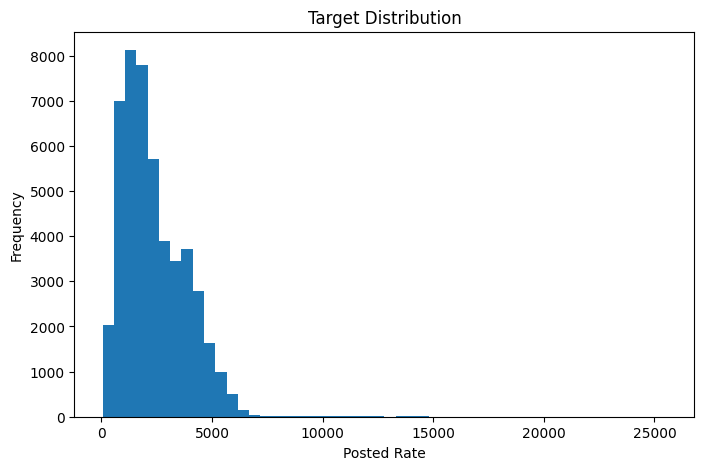

In [12]:
plt.figure(figsize=(8,5))

plt.hist(
    target,
    bins=50
)

plt.xlabel("Posted Rate")

plt.ylabel("Frequency")

plt.title("Target Distribution")

plt.show()

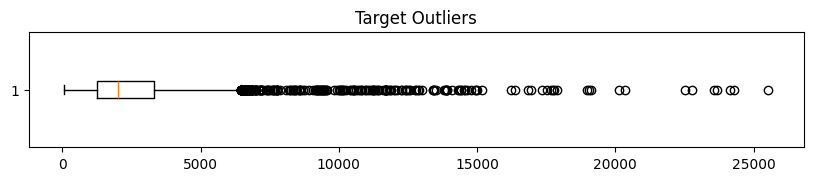

In [13]:
plt.figure(figsize=(10,1.5))

plt.boxplot(
    target,
    vert=False
)

plt.title("Target Outliers")

plt.show()

In [14]:
print("Skewness :", skew(target))

print("Kurtosis:", kurtosis(target))

Skewness : 1.9023354288641408
Kurtosis: 13.281913336644116


## 8. Numerical Feature Analysis

The numerical predictors are examined to understand their distributions, scale, potential outliers, and individual relationship with the target.

The analysis focuses on identifying transformations or feature-engineering opportunities that may improve model performance.

In [15]:
numeric_features = train.select_dtypes(include=np.number).columns.tolist()

numeric_features

['pickup_lat',
 'pickup_lon',
 'delivery_lat',
 'delivery_lon',
 'distance',
 'weight',
 'market_index',
 'quote_signal',
 'posted_rate']

In [16]:
numeric_features = [
    col for col in numeric_features
    if col != "posted_rate"
]

numeric_features

['pickup_lat',
 'pickup_lon',
 'delivery_lat',
 'delivery_lon',
 'distance',
 'weight',
 'market_index',
 'quote_signal']

In [17]:
train[numeric_features].describe().T

,count,mean,std,min,25%,50%,75%,max
pickup_lat,48000.0,35.647545,4.315285,28.35765,31.98691,35.29479,39.411040,44.30296
pickup_lon,48000.0,-90.928964,13.482431,-121.69849,-98.40059,-88.08915,-83.285060,-69.50000
delivery_lat,48000.0,35.641175,4.317199,28.35765,31.98691,35.29479,39.411040,44.30296
delivery_lon,48000.0,-90.857310,13.476589,-121.69849,-98.40059,-87.52871,-83.285060,-69.50000
distance,48000.0,1135.856654,728.564416,70.00000,550.40000,953.30000,1645.525000,3439.80000
weight,47700.0,31028.844004,9391.440620,-47500.00000,25800.00000,31436.50000,37018.000000,47500.00000
market_index,47626.0,1.083387,0.168091,0.67639,0.94967,1.05580,1.219590,1.46778
quote_signal,48000.0,2.062468,0.291391,0.69228,1.89103,2.05575,2.221685,3.61035


In [18]:
numeric_distribution = pd.DataFrame({
    "Feature": numeric_features,
    "Skewness": [
        train[col].skew()
        for col in numeric_features
    ],
    "Missing": [
        train[col].isna().sum()
        for col in numeric_features
    ]
})

numeric_distribution.sort_values(
    "Skewness",
    key=lambda x: x.abs(),
    ascending=False
)

,Feature,Skewness,Missing
5,weight,-1.910391,300
4,distance,0.765775,0
3,delivery_lon,-0.699329,0
1,pickup_lon,-0.693987,0
6,market_index,0.214263,374
2,delivery_lat,0.179351,0
0,pickup_lat,0.177336,0
7,quote_signal,0.171989,0


In [19]:
target_correlations = (
    train[numeric_features + ["posted_rate"]]
    .corr(numeric_only=True)["posted_rate"]
    .drop("posted_rate")
    .sort_values(key=lambda x: x.abs(), ascending=False)
)

target_correlations

distance        0.908519
delivery_lon   -0.257086
pickup_lon     -0.255058
delivery_lat   -0.091970
pickup_lat     -0.090873
quote_signal   -0.039858
weight          0.034840
market_index    0.034165
Name: posted_rate, dtype: float64

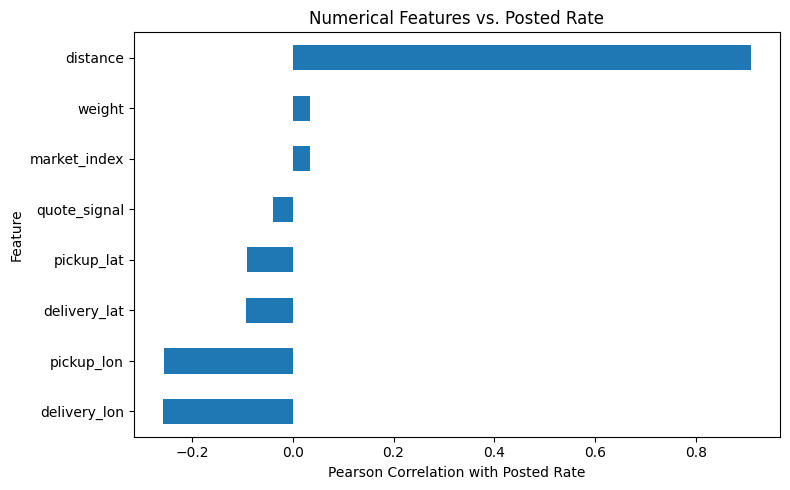

In [20]:
plt.figure(figsize=(8, 5))

target_correlations.sort_values().plot(kind="barh")

plt.xlabel("Pearson Correlation with Posted Rate")
plt.ylabel("Feature")
plt.title("Numerical Features vs. Posted Rate")

plt.tight_layout()
plt.show()

## 9. Categorical Feature Analysis

`equipment`, `pickup`, and `delivery` are examined for cardinality, class balance, and their relationship with `posted_rate`.

In [21]:
categorical_features = ["equipment", "pickup", "delivery"]

for col in categorical_features:
    print(f"{col}: {train[col].nunique()} unique values")

equipment: 3 unique values
pickup: 64 unique values
delivery: 64 unique values


In [22]:
equipment_summary = (
    train.groupby("equipment")["posted_rate"]
    .agg(["count", "mean", "median", "std"])
    .sort_values("mean", ascending=False)
)

equipment_summary

,count,mean,median,std
equipment,,,,
Reefer,12045,2553.636939,2196.670,1589.670824
Flatbed,8753,2445.087223,2076.810,1505.053087
Dry Van,27202,2271.548686,1953.035,1423.029914


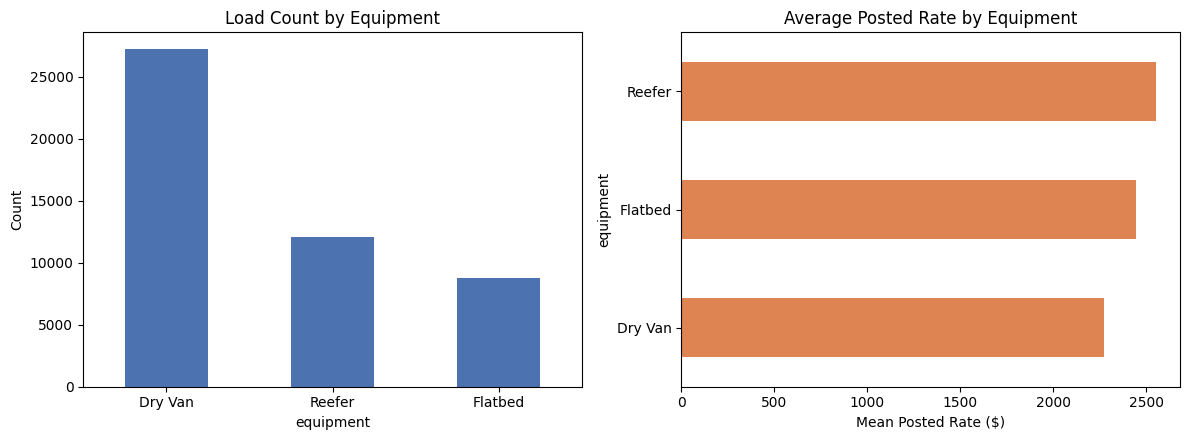

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

train["equipment"].value_counts().plot(
    kind="bar", ax=axes[0], color="#4C72B0"
)
axes[0].set_title("Load Count by Equipment")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=0)

equipment_summary["mean"].sort_values().plot(
    kind="barh", ax=axes[1], color="#DD8452"
)
axes[1].set_title("Average Posted Rate by Equipment")
axes[1].set_xlabel("Mean Posted Rate ($)")

plt.tight_layout()
plt.show()

In [24]:
lane_volume = (
    train.groupby(["pickup", "delivery"])
    .size()
    .sort_values(ascending=False)
)

print("Number of distinct pickup-delivery lanes:", lane_volume.shape[0])
print()
print("Top 10 lanes by volume:")
display(lane_volume.head(10))

print()
print("Bottom 10 lanes by volume:")
display(lane_volume.tail(10))

Number of distinct pickup-delivery lanes: 4014

Top 10 lanes by volume:


pickup      delivery     
Columbia    Oklahoma City    39
Phoenix     Shreveport       39
Lexington   Atlanta          39
Fort Wayne  Philadelphia     38
Shreveport  Hartford         37
Fort Wayne  Hartford         37
Richmond    Oklahoma City    37
            Phoenix          37
Lexington   Kansas City      37
            Cincinnati       37
dtype: int64


Bottom 10 lanes by volume:


pickup          delivery      
Madison         Salt Lake City    1
                St. Louis         1
Las Vegas       Reno              1
Salt Lake City  Dallas            1
                Detroit           1
Las Vegas       Tulsa             1
Salt Lake City  Baltimore         1
Dallas          Harrisburg        1
                Albuquerque       1
New Orleans     Dallas            1
dtype: int64

### Categorical Features - Key Findings

- `equipment` has 3 classes: Dry Van (~56.7%), Reefer (~25.1%), Flatbed (~18.2%). Reefer commands the highest average rate, followed by Flatbed, then Dry Van — consistent with the added handling/regulatory cost of refrigerated freight.
- `pickup` and `delivery` each contain 64 distinct cities in the training data, forming a large number of pickup–delivery lane combinations with uneven volume (some lanes appear far more often than others).
- Because `equipment` has low cardinality it is a safe candidate for one-hot encoding, while `pickup`/`delivery` (64 categories each, and combined into lanes) are better suited to target encoding, frequency encoding, or embeddings — with an explicit fallback for categories not seen in training (see Section 15).

## 10. Geographic Features - Coordinates & Distance

The dataset provides `pickup_lat/lon` and `delivery_lat/lon` in addition to a precomputed `distance` column. This section checks whether the coordinates carry information beyond city identity and whether `distance` is internally consistent.

In [25]:
# Are lat/lon fixed per city (i.e. redundant with the city name) or do they vary row to row?
coord_variability = (
    train.groupby("pickup")[["pickup_lat", "pickup_lon"]]
    .std()
    .fillna(0)
)

print("Max within-city std of pickup_lat/lon across all cities:")
print(coord_variability.max())

Max within-city std of pickup_lat/lon across all cities:
pickup_lat    0.0
pickup_lon    0.0
dtype: float64


In [26]:
def haversine_miles(lat1, lon1, lat2, lon2):
    R = 3958.8
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))

train["haversine_distance"] = haversine_miles(
    train["pickup_lat"], train["pickup_lon"],
    train["delivery_lat"], train["delivery_lon"],
)

print("Correlation between reported distance and great-circle (haversine) distance:")
print(train[["distance", "haversine_distance"]].corr().iloc[0, 1])

train[["distance", "haversine_distance"]].describe()

Correlation between reported distance and great-circle (haversine) distance:
0.9995349596237224


,distance,haversine_distance
count,48000.000000,48000.000000
mean,1135.856654,966.154360
std,728.564416,630.650711
min,70.000000,7.265240
25%,550.400000,456.537929
50%,953.300000,806.935637
75%,1645.525000,1410.670791
max,3439.800000,2873.652583


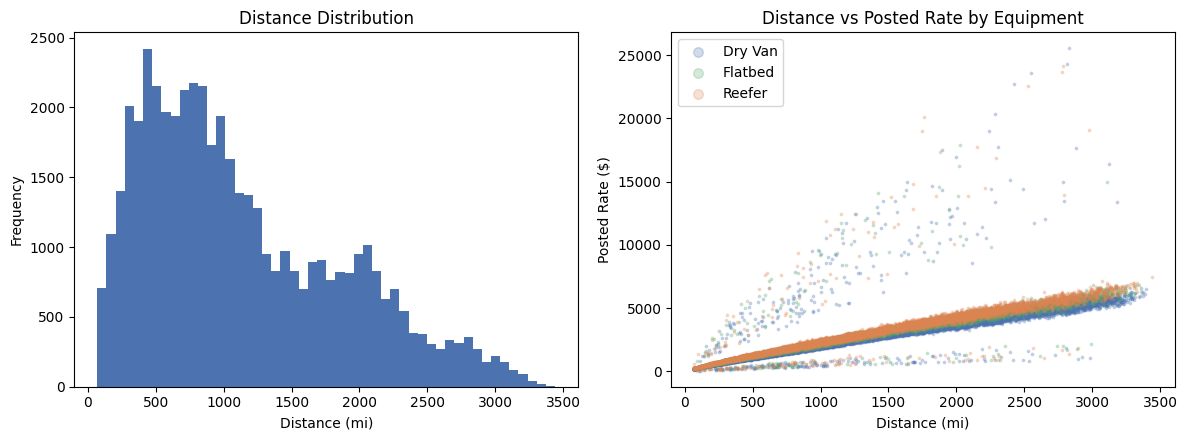

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].hist(train["distance"], bins=50, color="#4C72B0")
axes[0].set_title("Distance Distribution")
axes[0].set_xlabel("Distance (mi)")
axes[0].set_ylabel("Frequency")

colors = {"Dry Van": "#4C72B0", "Reefer": "#DD8452", "Flatbed": "#55A868"}
for eq, sub in train.groupby("equipment"):
    axes[1].scatter(
        sub["distance"], sub["posted_rate"],
        s=3, alpha=0.25, label=eq, color=colors.get(eq),
    )
axes[1].set_title("Distance vs Posted Rate by Equipment")
axes[1].set_xlabel("Distance (mi)")
axes[1].set_ylabel("Posted Rate ($)")
axes[1].legend(markerscale=4)

plt.tight_layout()
plt.show()

### Geographic Features - Key Findings

- Within-city standard deviation of `pickup_lat`/`pickup_lon` is 0 for every city: coordinates are fixed per city, so `pickup_lat/lon` and `delivery_lat/lon` carry no information beyond `pickup`/`delivery` themselves.
- The reported `distance` column correlates 0.9995 with the great-circle distance computed from coordinates, confirming `distance` is internally consistent (approximately great-circle distance scaled up by a road-circuity factor) and reliable to use directly.
- **Recommendation:** drop the four lat/lon columns from modeling (redundant with `pickup`/`delivery`/`distance`) to reduce dimensionality without losing information.
- `distance` is the single strongest driver of `posted_rate` (Pearson r ≈ 0.91), and the relationship is visibly non-linear — worth capturing with `log(distance)`, polynomial terms, or a tree-based model.

## 11. Rate-per-Mile Analysis

Because `distance` dominates `posted_rate`, it is useful to analyze `posted_rate / distance` (rate-per-mile) to see how the *remaining* variation behaves.

In [28]:
train["rate_per_mile"] = train["posted_rate"] / train["distance"]

train["rate_per_mile"].describe()

count    48000.000000
mean         2.215347
std          0.583887
min          0.333709
25%          1.986974
50%          2.145348
75%          2.342696
max         14.125294
Name: rate_per_mile, dtype: float64

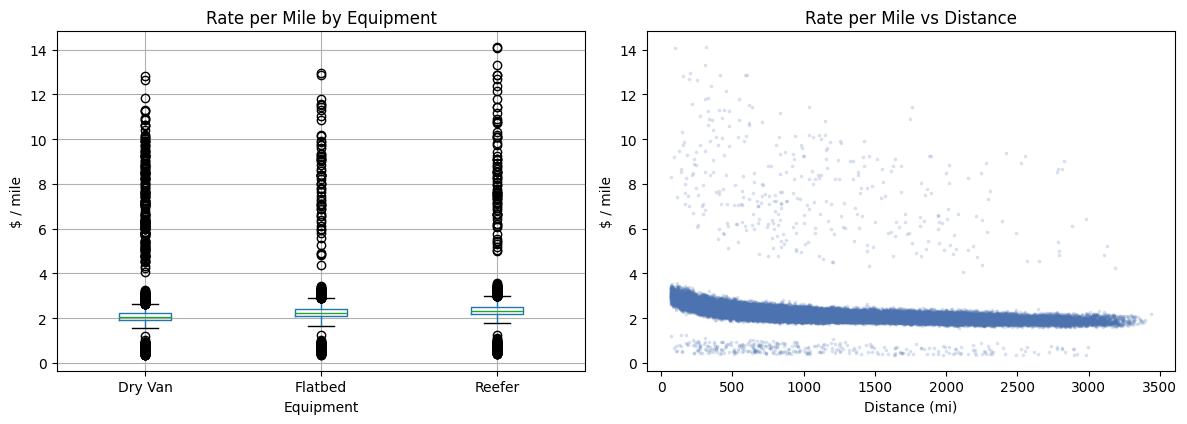

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

train.boxplot(column="rate_per_mile", by="equipment", ax=axes[0])
axes[0].set_title("Rate per Mile by Equipment")
axes[0].set_xlabel("Equipment")
axes[0].set_ylabel("$ / mile")
plt.suptitle("")

axes[1].scatter(train["distance"], train["rate_per_mile"], s=3, alpha=0.15, color="#4C72B0")
axes[1].set_title("Rate per Mile vs Distance")
axes[1].set_xlabel("Distance (mi)")
axes[1].set_ylabel("$ / mile")

plt.tight_layout()
plt.show()

### Rate-per-Mile - Key Findings

- Median rate-per-mile is about $2.15/mi, with Reefer > Flatbed > Dry Van, mirroring the equipment ranking seen in Section 9.
- Rate-per-mile is **not constant across distance** — it is higher (and more variable) for short-haul loads and declines steadily as distance increases, flattening out beyond roughly 1,500–2,000 miles. This is consistent with fixed per-load costs being amortized over the trip length.
- Implication for modeling: a simple linear `posted_rate ~ distance` model will systematically misprice short hauls. A log-distance term, spline, or non-linear model (e.g. gradient-boosted trees) is better suited to capturing this curve.

## 12. Market Signal Features - `market_index` & `quote_signal`

`market_index` and `quote_signal` show weak direct (raw) correlation with `posted_rate` in Section 8. This section checks whether they act *multiplicatively* with `distance` instead.

In [30]:
train[["market_index", "quote_signal"]].describe()

,market_index,quote_signal
count,47626.000000,48000.000000
mean,1.083387,2.062468
std,0.168091,0.291391
min,0.676390,0.692280
25%,0.949670,1.891030
50%,1.055800,2.055750
75%,1.219590,2.221685
max,1.467780,3.610350


In [31]:
print("Correlation between market_index and quote_signal:",
      train[["market_index", "quote_signal"]].corr().iloc[0, 1])

print()
print("Raw correlation with posted_rate:")
print(train[["market_index", "quote_signal"]].corrwith(train["posted_rate"]))

print()
print("Correlation with posted_rate AFTER multiplying by distance:")
interaction_corr = pd.Series({
    "market_index * distance": (train["market_index"] * train["distance"]).corr(train["posted_rate"]),
    "quote_signal * distance": (train["quote_signal"] * train["distance"]).corr(train["posted_rate"]),
})
print(interaction_corr)

Correlation between market_index and quote_signal: -0.06782710398018567

Raw correlation with posted_rate:
market_index    0.034165
quote_signal   -0.039858
dtype: float64

Correlation with posted_rate AFTER multiplying by distance:
market_index * distance    0.884687
quote_signal * distance    0.898688
dtype: float64


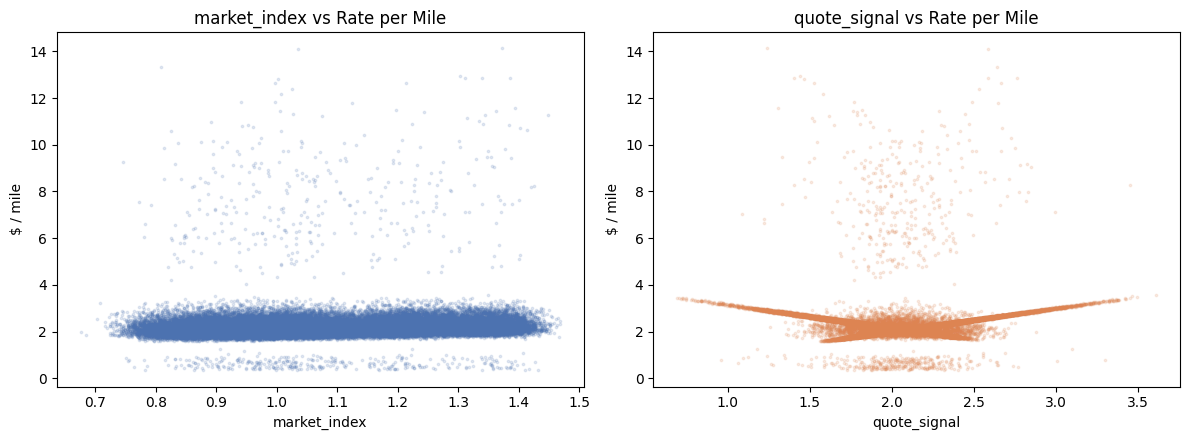

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].scatter(train["market_index"], train["rate_per_mile"], s=3, alpha=0.15, color="#4C72B0")
axes[0].set_title("market_index vs Rate per Mile")
axes[0].set_xlabel("market_index")
axes[0].set_ylabel("$ / mile")

axes[1].scatter(train["quote_signal"], train["rate_per_mile"], s=3, alpha=0.15, color="#DD8452")
axes[1].set_title("quote_signal vs Rate per Mile")
axes[1].set_xlabel("quote_signal")
axes[1].set_ylabel("$ / mile")

plt.tight_layout()
plt.show()

### Market Signal Features - Key Findings

- `market_index` and `quote_signal` are nearly uncorrelated with each other (r ≈ -0.07), so they carry distinct information rather than duplicating one another.
- Both have **weak raw correlation** with `posted_rate` (~0.03 to -0.04) but **strong correlation once multiplied by `distance`** (0.88 and 0.90 respectively) - confirming these are multiplicative market-condition signals that scale the base distance-driven rate, not additive offsets.
- **Feature engineering implication:** create explicit interaction terms (`market_index * distance`, `quote_signal * distance`) for linear-model candidates. Tree-based models can often learn this interaction natively from the raw features, but the engineered terms are still useful as a sanity check and for feature-importance interpretation.
- Both columns have missing values (Section 6) and are **entirely absent from `december-chart-inputs.csv`**, so any final model must have a documented strategy for predicting without them (see Sections 14 and 17).

## 13. Temporal Analysis & Seasonality

`train-test.csv` spans January–October 2025, `validation.csv` is November 2025, and the December chart requires predicting into an unseen future month. This section checks for seasonality and trend that a model would need to extrapolate.

In [33]:
train["date"] = pd.to_datetime(train["date"])
train["month"] = train["date"].dt.month
train["day_of_week"] = train["date"].dt.day_name()

print("Training data date range:", train["date"].min().date(), "to", train["date"].max().date())

Training data date range: 2025-01-01 to 2025-10-31


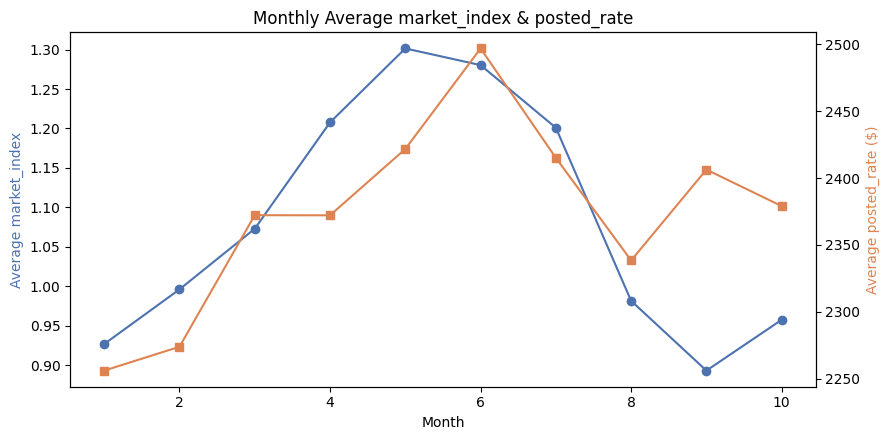

In [34]:
monthly = train.groupby("month").agg(
    avg_posted_rate=("posted_rate", "mean"),
    avg_market_index=("market_index", "mean"),
).reset_index()

fig, ax1 = plt.subplots(figsize=(9, 4.5))

ax1.plot(monthly["month"], monthly["avg_market_index"], marker="o", color="#4C72B0", label="market_index")
ax1.set_xlabel("Month")
ax1.set_ylabel("Average market_index", color="#4C72B0")

ax2 = ax1.twinx()
ax2.plot(monthly["month"], monthly["avg_posted_rate"], marker="s", color="#DD8452", label="posted_rate")
ax2.set_ylabel("Average posted_rate ($)", color="#DD8452")

plt.title("Monthly Average market_index & posted_rate")
plt.tight_layout()
plt.show()

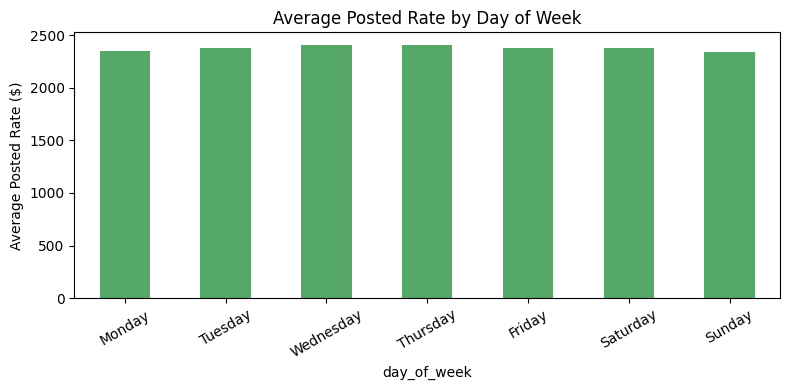

In [35]:
dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

train.groupby("day_of_week")["posted_rate"].mean().reindex(dow_order).plot(
    kind="bar", figsize=(8, 4), color="#55A868"
)
plt.title("Average Posted Rate by Day of Week")
plt.ylabel("Average Posted Rate ($)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### Temporal Analysis - Key Findings

- Both `market_index` and average `posted_rate` follow a clear **seasonal cycle**: rising from January, peaking around May–June, then declining through September, with a slight uptick in October.
- Day-of-week effects are minor compared to the monthly seasonal swing.
- Because `validation.csv` (November) and `december-chart-inputs.csv` (December) fall **after** the last training date (October 31), the model will need to **extrapolate the seasonal trend beyond the observed range** rather than interpolate within it. This is the key reason a *random* train/validation split would overstate real-world performance — see Section 15 and the modeling notebook for the time-based split used instead.

## 14. Data Quality Issues

This section investigates anomalies beyond simple missingness: implausible values, outlier rate-per-mile observations, and whether missingness itself is random or systematic.

In [36]:
# Issue 1: negative weight values
negative_weight = train[train["weight"] < 0]

print(f"Negative weight rows: {len(negative_weight)} ({len(negative_weight) / len(train) * 100:.2f}%)")
print()
print("Negative weight range:", negative_weight["weight"].min(), "to", negative_weight["weight"].max())
print("Positive weight range:", train.loc[train['weight'] > 0, 'weight'].min(), "to", train.loc[train['weight'] > 0, 'weight'].max())

Negative weight rows: 292 (0.61%)

Negative weight range: -47500.0 to -5000.0
Positive weight range: 5000.0 to 47500.0


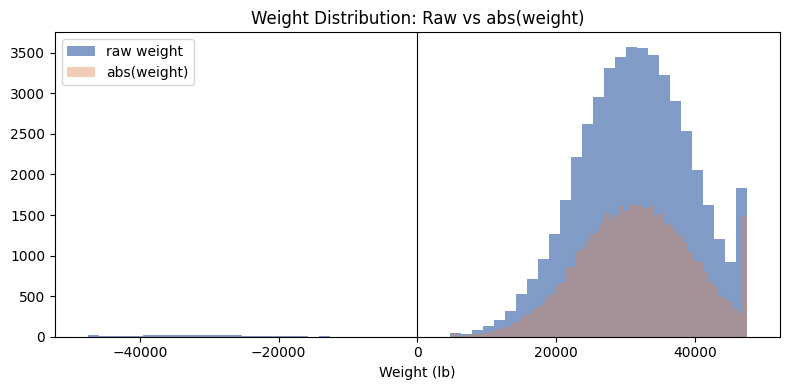

In [37]:
# The negative range is a near-exact mirror of the positive range, consistent with a sign-flip
# data-entry error rather than genuinely negative weight. abs(weight) is used as the correction.

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(train["weight"].dropna(), bins=60, color="#4C72B0", alpha=0.7, label="raw weight")
ax.hist(train["weight"].dropna().abs(), bins=60, color="#DD8452", alpha=0.4, label="abs(weight)")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Weight Distribution: Raw vs abs(weight)")
ax.set_xlabel("Weight (lb)")
ax.legend()
plt.tight_layout()
plt.show()

In [38]:
# Issue 2: rate-per-mile outliers (independent of the weight issue)
rpm_outliers = train[(train["rate_per_mile"] < 1.0) | (train["rate_per_mile"] > 3.5)]

print(f"Rate-per-mile outlier rows (outside [1.0, 3.5]): {len(rpm_outliers)} "
      f"({len(rpm_outliers) / len(train) * 100:.2f}%)")

overlap = rpm_outliers.index.isin(negative_weight.index).sum()
print(f"Overlap with negative-weight rows: {overlap} of {len(rpm_outliers)} "
      "-> the two issues are largely independent")

display(rpm_outliers.sort_values("rate_per_mile")[
    ["pickup", "delivery", "distance", "equipment", "weight", "posted_rate", "rate_per_mile"]
].head(10))

Rate-per-mile outlier rows (outside [1.0, 3.5]): 671 (1.40%)
Overlap with negative-weight rows: 9 of 671 -> the two issues are largely independent


,pickup,delivery,distance,equipment,weight,posted_rate,rate_per_mile
14102,Buffalo,Bakersfield,2536.4,Dry Van,27044.0,846.42,0.333709
25798,Albany,Reno,2894.3,Dry Van,32383.0,969.83,0.335083
23043,Phoenix,Philadelphia,2983.4,Dry Van,37692.0,1047.91,0.351247
46173,Philadelphia,El Paso,2490.9,Dry Van,22411.0,880.13,0.353338
508,Las Vegas,Grand Rapids,1976.4,Flatbed,28233.0,699.41,0.353881
2511,Buffalo,San Antonio,1644.3,Flatbed,22022.0,596.04,0.362489
40600,Fort Wayne,Phoenix,2210.6,Dry Van,24954.0,808.74,0.365846
22458,Salt Lake City,Mobile,1632.3,Dry Van,-32048.0,599.77,0.367439
22464,Kansas City,Los Angeles,1909.1,Dry Van,32899.0,709.46,0.371620
1555,El Paso,New York,2415.0,Dry Van,39284.0,911.44,0.377408


In [39]:
# Issue 3: is missingness random, or systematic (tied to equipment / time)?
missing_by_equipment = train.assign(
    weight_missing=train["weight"].isna(),
    market_index_missing=train["market_index"].isna(),
).groupby("equipment")[["weight_missing", "market_index_missing"]].mean()

missing_by_month = train.assign(
    weight_missing=train["weight"].isna()
).groupby("month")["weight_missing"].mean()

print("Missing rate by equipment:")
display(missing_by_equipment)

print("Missing weight rate by month:")
display(missing_by_month)

Missing rate by equipment:


,weight_missing,market_index_missing
equipment,,
Dry Van,0.006433,0.007426
Flatbed,0.006284,0.008340
Reefer,0.005812,0.008219


Missing weight rate by month:


month
1     0.006913
2     0.007609
3     0.007149
4     0.004150
5     0.004478
6     0.006690
7     0.005904
8     0.006094
9     0.007066
10    0.006594
Name: weight_missing, dtype: float64

### Data Quality Issues - Key Findings

1. **Negative weights**: 292 rows (0.61%) have negative `weight`, with a range that mirrors the positive range almost exactly (e.g. -47,500 to 47,500 vs the true 0-47,500 span). This points to a **sign-flip entry error** rather than genuinely negative weight. **Fix:** apply `abs(weight)`.
2. **Rate-per-mile outliers**: 671 rows (1.40%) fall well outside the tight rate-per-mile band the rest of the data follows. Only 9 of these overlap with the negative-weight rows, so this is a **separate issue**, likely noise or mispriced loads. **Fix:** flag or winsorize these rows for the linear-model baseline; tree-based models can be left to absorb them, but the choice should be documented and tested.
3. **Missingness pattern**: missing-value rates for `weight` and `market_index` are flat across `equipment` and across months, consistent with values missing completely at random (MCAR) rather than tied to a specific condition. This supports using a simple imputer (e.g. median, or a model-based imputer) rather than a conditional/rule-based one.

## 15. Train vs Validation Distribution Shift

`validation.csv` covers November 2025, a month never seen in training. This section checks whether its feature distributions match training data closely enough for the model to generalize, and flags any categories the model will encounter for the first time.

In [40]:
numeric_compare = pd.DataFrame({
    "train_mean": train[numeric_features].mean(),
    "validation_mean": validation[numeric_features].mean(),
    "train_std": train[numeric_features].std(),
    "validation_std": validation[numeric_features].std(),
})

numeric_compare

,train_mean,validation_mean,train_std,validation_std
pickup_lat,35.647545,35.574216,4.315285,4.366999
pickup_lon,-90.928964,-90.724880,13.482431,13.411638
delivery_lat,35.641175,35.609538,4.317199,4.351844
delivery_lon,-90.857310,-90.913530,13.476589,13.624744
distance,1135.856654,1141.773100,728.564416,732.333797
weight,31028.844004,30506.636248,9391.440620,10572.590450
market_index,1.083387,0.926913,0.168091,0.074109
quote_signal,2.062468,2.051334,0.291391,0.219804


In [41]:
equipment_compare = pd.concat([
    train["equipment"].value_counts(normalize=True).rename("train"),
    validation["equipment"].value_counts(normalize=True).rename("validation"),
], axis=1)

equipment_compare

,train,validation
equipment,,
Dry Van,0.566708,0.56500
Reefer,0.250937,0.25425
Flatbed,0.182354,0.18075


In [42]:
train_pickups = set(train["pickup"]) | set(train["delivery"])
validation_pickups = set(validation["pickup"]) | set(validation["delivery"])

unseen_cities = validation_pickups - train_pickups

print(f"Cities appearing in validation that never appear in training: {len(unseen_cities)}")
print(sorted(unseen_cities))

unseen_rows = validation[
    validation["pickup"].isin(unseen_cities) | validation["delivery"].isin(unseen_cities)
]
print(f"\nValidation rows affected: {len(unseen_rows)} ({len(unseen_rows) / len(validation) * 100:.2f}%)")

Cities appearing in validation that never appear in training: 8
['Allentown', 'Charlotte', 'Chicago', 'Jackson', 'Knoxville', 'Laredo', 'Norfolk', 'San Diego']

Validation rows affected: 1447 (12.06%)


In [43]:
missing_compare = pd.DataFrame({
    "train_missing_pct": train[["weight", "market_index"]].isna().mean() * 100,
    "validation_missing_pct": validation[["weight", "market_index"]].isna().mean() * 100,
})

missing_compare.round(2)

,train_missing_pct,validation_missing_pct
weight,0.62,1.38
market_index,0.78,2.08


### Train vs Validation Shift - Key Findings

- `distance` and `weight` distributions are very close between train and validation. `market_index` is **narrower and lower on average** in validation (consistent with November sitting in the low part of the seasonal cycle identified in Section 13), which is expected seasonal shift rather than a data problem.
- `equipment` class proportions are essentially identical between the two sets.
- **8 cities appear in validation that never appear in training** (Knoxville, Jackson, Charlotte, Norfolk, Allentown, Chicago, Laredo, San Diego), affecting a non-trivial share of validation rows. **Any categorical encoding of `pickup`/`delivery` must have an explicit unseen-category fallback** (e.g. a shared "unknown city" bucket, or falling back to a distance/region-only prediction for those rows), or the pipeline will fail or silently degrade on them.
- The missing-value rate for `weight` and `market_index` is roughly double in validation versus train — the imputation strategy chosen should be validated to make sure it still behaves sensibly at that higher missing rate.

## 16. Correlation Heatmap (Including Engineered Interaction Features)

A combined correlation view of the raw numeric features plus the interaction terms identified in Sections 11-12.

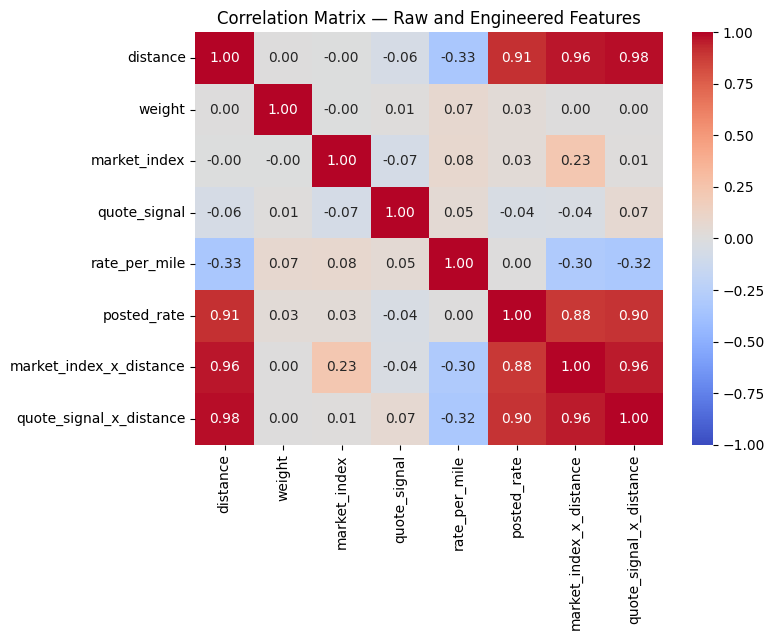

In [44]:
corr_features = train[[
    "distance", "weight", "market_index", "quote_signal",
    "rate_per_mile", "posted_rate",
]].copy()

corr_features["market_index_x_distance"] = train["market_index"] * train["distance"]
corr_features["quote_signal_x_distance"] = train["quote_signal"] * train["distance"]

corr_matrix = corr_features.corr()

plt.figure(figsize=(8, 6.5))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Correlation Matrix — Raw and Engineered Features")
plt.tight_layout()
plt.show()

### Correlation Heatmap - Key Findings

- `distance` remains the dominant single correlate of `posted_rate` (~0.91).
- The engineered interaction terms `market_index * distance` and `quote_signal * distance` correlate far more strongly with `posted_rate` (0.88-0.90) than either raw signal alone, confirming the multiplicative relationship found in Section 12 and motivating their inclusion as engineered features for linear-style models.
- `weight` remains weakly correlated with `posted_rate` throughout - it may still add marginal predictive value in a non-linear model, but should not be expected to be a primary driver.

## 17. December Chart-Input File Check

`december-chart-inputs.csv` is used only to produce the fixed December prediction chart via `score.py`. It has a different, smaller schema than `train-test.csv` / `validation.csv`, so it is checked separately.

In [45]:
print("December file columns:", list(december.columns))
print("Train/validation columns:", list(train.columns[:13]))
print()
print("Columns present in train but missing from december:",
      set(train.columns) - set(december.columns))

December file columns: ['pickup', 'delivery', 'distance', 'equipment', 'weight', 'date', 'predicted_rate']
Train/validation columns: ['load_id', 'pickup', 'delivery', 'pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'distance', 'equipment', 'weight', 'date', 'market_index', 'quote_signal']

Columns present in train but missing from december: {'month', 'quote_signal', 'delivery_lat', 'pickup_lat', 'delivery_lon', 'haversine_distance', 'load_id', 'market_index', 'posted_rate', 'rate_per_mile', 'day_of_week', 'pickup_lon'}


In [46]:
december.describe(include="all")

,pickup,delivery,distance,equipment,weight,date,predicted_rate
count,31,31,31.0,31,31.0,31,0.0
unique,1,1,NaN,1,NaN,31,NaN
top,Lexington,Fort Wayne,NaN,Dry Van,NaN,2025-12-01,NaN
freq,31,31,NaN,31,NaN,1,NaN
mean,NaN,NaN,360.0,NaN,32000.0,NaN,NaN
std,NaN,NaN,0.0,NaN,0.0,NaN,NaN
min,NaN,NaN,360.0,NaN,32000.0,NaN,NaN
25%,NaN,NaN,360.0,NaN,32000.0,NaN,NaN
50%,NaN,NaN,360.0,NaN,32000.0,NaN,NaN
75%,NaN,NaN,360.0,NaN,32000.0,NaN,NaN


### December File - Key Findings

- The December file fixes `pickup` (Lexington), `delivery` (Fort Wayne), `distance` (360 mi), `equipment` (Dry Van), and `weight` (32,000 lb) for all 31 rows - only `date` varies across the month.
- It does **not** include `market_index` or `quote_signal`, the two features shown in Sections 12 and 16 to carry most of the non-distance predictive signal. Producing December predictions therefore requires either: (a) a model variant trained without these two columns, or (b) an explicit, documented way to estimate them for December (e.g. extrapolating the seasonal pattern from Section 13). This is a design decision to make explicitly in the modeling stage and to explain in the written report.

## 18. Summary of Key EDA Findings

- **Target**: `posted_rate` is right-skewed (skew ≈ 1.9); both raw and log-transformed targets should be evaluated during modeling.
- **Primary driver**: `distance` (r ≈ 0.91), with a non-linear, diminishing rate-per-mile as distance increases.
- **Market signals**: `market_index` and `quote_signal` act multiplicatively with `distance` rather than additively — raw correlations are weak, but `signal * distance` correlations are strong (0.88-0.90).
- **Equipment**: Reefer > Flatbed > Dry Van in both average rate and rate-per-mile; low cardinality, safe to one-hot encode.
- **Geography**: `pickup_lat/lon` and `delivery_lat/lon` are redundant with the city names and can be dropped; `distance` is internally consistent with them.
- **Seasonality**: Clear monthly cycle peaking in late spring/early summer. Validation (November) and the December chart both fall outside the training window, so the model must extrapolate the seasonal trend — this should drive a **time-based train/validation split**, not a random one.
- **Data quality issues found and how they will be addressed**:
  1. Negative `weight` values (sign-flip error, 0.6-1.4% of rows) → corrected with `abs(weight)`.
  2. Rate-per-mile outliers (~1.4% of rows, independent of the weight issue) → flagged for capping/winsorizing or left for tree-based models to absorb, decision to be validated empirically.
  3. Missing `weight` and `market_index` (missing completely at random, higher rate in validation) → imputed (e.g. median or model-based imputer), with the strategy validated at validation's higher missing rate.
  4. 8 cities in validation unseen during training → categorical encoding must include an explicit unseen-category fallback.
  5. `december-chart-inputs.csv` lacks `market_index`/`quote_signal` entirely → requires a documented no-market-signal model variant or a seasonal estimate of those columns.

These findings directly inform the feature engineering and modeling notebook that follows.